# Project 3 Task 2 Linear and Multivariable Regression - Python SKlearn



**Sivert Tilset (273412) and Robel Weldemichael(267200) and Mohammed Jama()**

Date: **10.11.2024**

# Abstact
In this task, we developed linear and multivariable regression models to predict the compressional wave velocity (Vp) based on selected features such as shear wave velocity (Vs), density (DEN), and neutron porosity (NEU). Using the sklearn.linear_model library, we built regression models to evaluate the impact of each feature individually and in combination on Vp prediction accuracy. Model performance was assessed through R-squared (R²) and RMSE values, which highlighted the predictive power of different feature combinations. By comparing our results with established geological models, including Gardner’s and Castagna’s equations, we validated the model’s reliability in a real-world context. This task reinforced the importance of feature selection and performance evaluation in regression modeling, providing insights into effective predictive modeling for geological data.


# Introduction
Regression modeling is a fundamental technique in data analysis, especially for predicting target variables based on multiple features. In this task, we applied linear and multivariable regression models to explore the relationships between compressional wave velocity (Vp) and other key geological features: shear wave velocity (Vs), density (DEN), and neutron porosity (NEU). The objective was to develop predictive models that could accurately estimate Vp based on these features, using Python’s Scikit-learn library for streamlined modeling and evaluation.

The task was structured to assess both single-feature (linear) and multi-feature (multivariable) models, enabling a comparison of how each individual feature and combination of features influenced model accuracy. Performance metrics such as R-squared (R²) and Root Mean Square Error (RMSE) were used to evaluate model effectiveness, highlighting which feature combinations were most predictive.

Additionally, we compared our models with established empirical models like Gardner’s and Castagna’s to gauge the reliability of our predictions against well-known geological standards. This comparison underscored the value of regression modeling in geological data analysis and highlighted how machine learning models can complement traditional empirical methods.

This task provides a foundation for understanding the complexities of feature selection, model accuracy, and validation, which are essential skills in predictive modeling.

# Linear and Multivariable Regression Modeling

In [2]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split # For data splitting 
from sklearn.linear_model import LinearRegression # For modelling of the splitted dataset 
from sklearn.metrics import mean_squared_error, r2_score  # For model accuracy preformance analysis


[1.60523928] 0.5447870467763187
x_v
Mean Squared Error: 0.0330106716732661
Root Mean Squared Error: 0.1816883916855067
R-Square: 0.6881073434998293


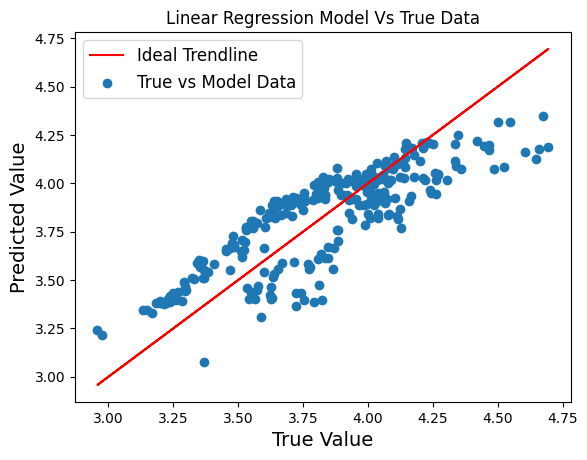

My_Model R2= 0.673697267992873
[2.52178778] -2.2454605112706743
x_d
Mean Squared Error: 0.032963639055586205
Root Mean Squared Error: 0.18155891345672404
R-Square: 0.6885517188283754


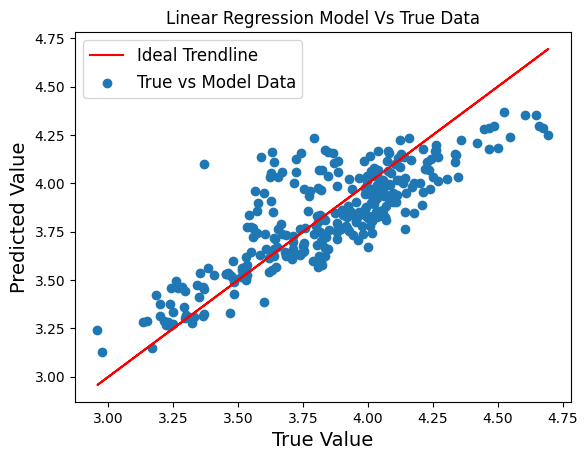

My_Model R2= 0.6584419480418571
[-4.99170335] 4.895522672215784
x_n
Mean Squared Error: 0.024392874377818053
Root Mean Squared Error: 0.15618218329187888
R-Square: 0.7695303365931213


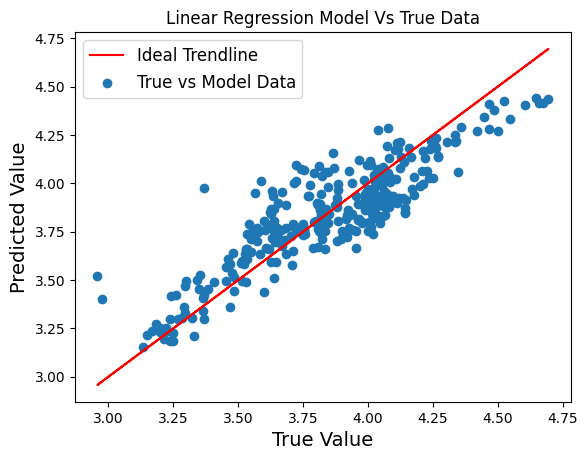

My_Model R2= 0.7609461378884727
[ 0.26431728 -4.52137674] 4.158280779667105
x_dn
Mean Squared Error: 0.024456826347984253
Root Mean Squared Error: 0.15638678444160253
R-Square: 0.768926103208809


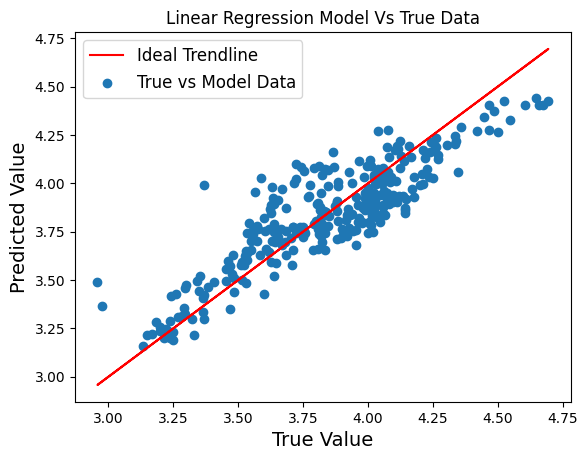

My_Model R2= 0.7584583684919023
[1.84965135 1.14344496] -2.968663971099252
x_dv
Mean Squared Error: 0.00647097744255358
Root Mean Squared Error: 0.08044238585816298
R-Square: 0.9388606701285267


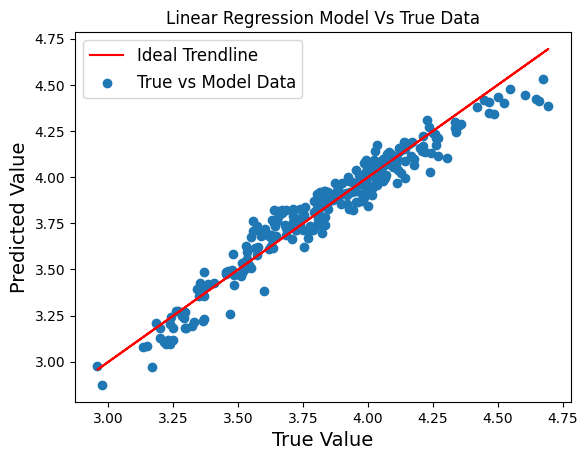

My_Model R2= 0.9334687908240822
[ 1.01613437 -3.59422765] 2.5157566411881342
x_vn
Mean Squared Error: 0.007031162407859839
Root Mean Squared Error: 0.08385202685600295
R-Square: 0.9335679096936542


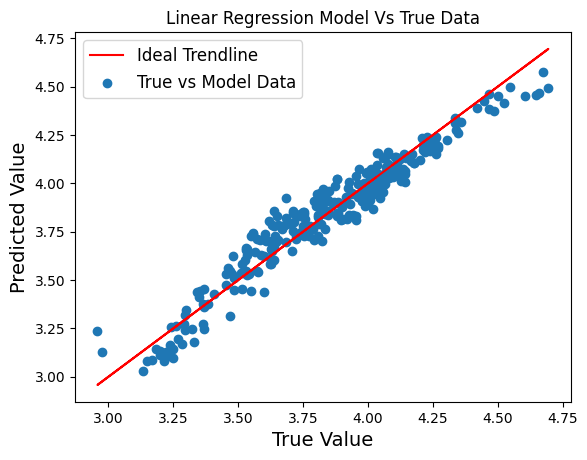

My_Model R2= 0.9342147054586063
[ 1.2233635   1.08244255 -1.32617988] -1.051778887512004
x_dvn
Mean Squared Error: 0.00584305464569419
Root Mean Squared Error: 0.07643987601830729
R-Square: 0.9447934336641471


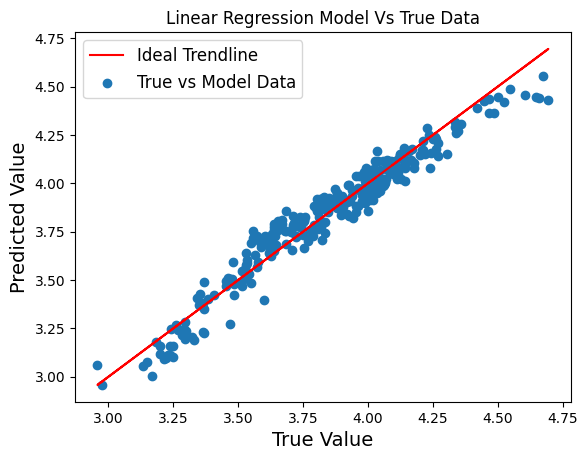

My_Model R2= 0.942202880376969
r_adjusted = 0.9442357915799466


In [8]:
# Step 2: Import/Reading the dataset of synthetic and pre-processed drilling data with file name synthetic.xlsx: 
df=pd.read_excel('CleanedFeatureSelected.xlsx')




feature_set_1 = {
    'x_v': df[['Vs']],
    'x_d': df[['DEN']],
    'x_n': df[['NEU']],
    'x_dn': df[['DEN', 'NEU']],
    'x_dv': df[['DEN', 'Vs']],
    'x_vn': df[['Vs', 'NEU']],
    'x_dvn': df[['DEN', 'Vs', 'NEU']]
}
y = df['Vp']  # Here use singe parenthesis


    




#Step 3c: Split the data for training (70%) and testing (30%)
for name, X in feature_set_1.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Step 4 Machine learning modeling and prediction
#We use a class called lineraRegression model to perform training.
# Class LinearRegression as a function called .fit() used to generate the optimized coefficients
    regressor = LinearRegression()  
    regressor.fit(X_train, y_train) #Fit function

    # Step 5 Prediction
    # Class LinearRegression as a function called .predict() used to perform model prediction by using the optimized coefficients
    y_pred = regressor.predict(X_test)

    # If we want to see the optimized coefficients, we will use print(use....coef_,  regressor.intercept_ )
    print (regressor.coef_,regressor.intercept_)
    #print( regressor.coef_[0])

    # Step 6 Model Performance Accuracy Evaluations
    # Function to calculate the R^2 based on the predicted and true dataset:
    mse = mean_squared_error(y_test, y_pred)  # Mean square sum error between the prediction and the true value
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Root means square error between the prediction and the true value
    r2 = r2_score(y_test, y_pred)  # Regression coefficient 
    print(name)
    print('Mean Squared Error:', mse)
    print('Root Mean Squared Error:',rmse)
    print('R-Square:',r2 )

    # Step 7 Plotting
    # Scatter plot (Predicted vs True) and Ideal Trendline
    plt.plot(y_test,y_test, '-r')
    plt.scatter(y_test, y_pred)

    plt.title('Linear Regression Model Vs True Data')
    plt.xlabel('True Value',fontsize=14)
    plt.ylabel('Predicted Value',fontsize=14)
    plt.legend(['Ideal Trendline', 'True vs Model Data'], loc='upper left', fontsize=12)
    plt.show()


    # Step 8 Co computation and performance analysis and plotting

    Co_true = np.array(0.77*y_test**2.93)
    Co_my_model = 0.77*y_pred**2.93
    Co_Castagna =np.array(0.77*(1.16*X_test + 1.36)**2.93)
    print('My_Model R2=', r2_score(Co_true, Co_my_model))  # Regression coefficient 


def r2_adj(n,p):
    return 1-(1-r2)*(n-1)/(n-p-1)

n = len(y_pred)
p = 3
print('r_adjusted =', r2_adj(n,p))  
#plt.plot(Co_true)
#plt.plot(Co_my_model)
#plt.show()

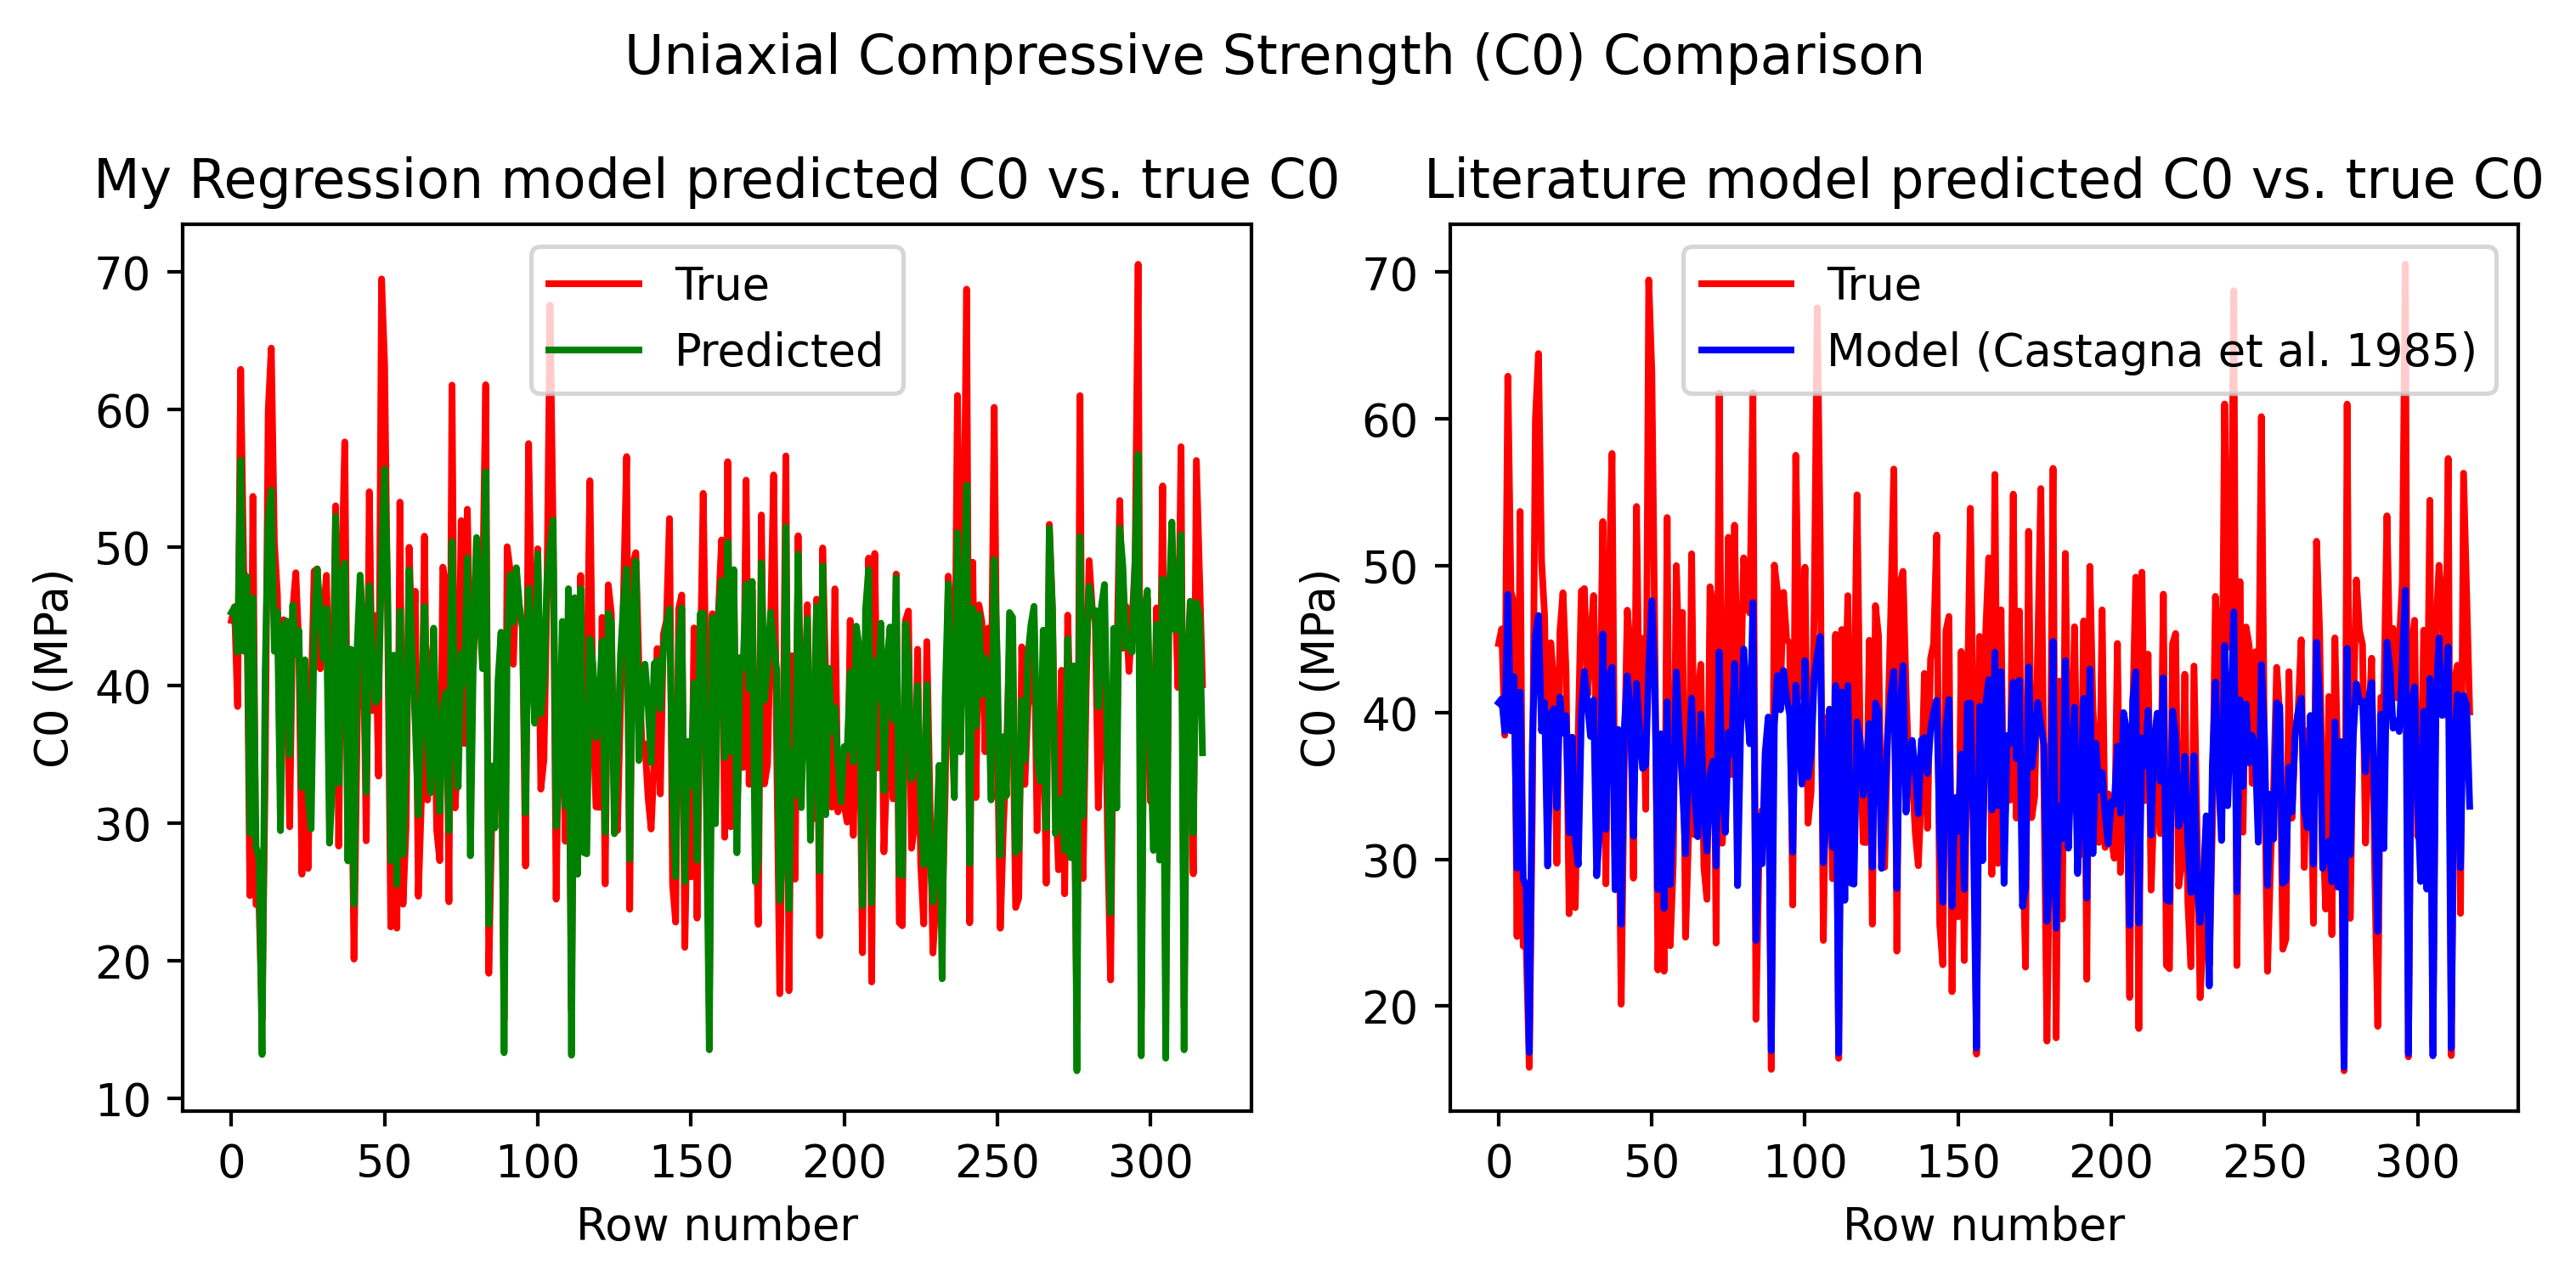

In [278]:
# Creating subplots
fig, axes = plt.subplots(1, 2, figsize=(8,4), dpi = 380)

fig.suptitle("Uniaxial Compressive Strength (C0) Comparison")
# Plotting regression model predicted C0 and true C0
axes[0].plot(Co_true, label = "True", color = "red")
axes[0].plot(Co_my_model, label = "Predicted", color = "green")
axes[0].set_xlabel("Row number")
axes[0].set_ylabel("C0 (MPa)")
axes[0].set_title("My Regression model predicted C0 vs. true C0")
axes[0].legend()


# Plotting literature model (Castagna et al. (1985)) predicted C0 and true C0
axes[1].plot(Co_true, label = "True", color = "red")
axes[1].plot(Co_Castagna, label = "Model (Castagna et al. 1985)", color = "blue")
axes[1].set_xlabel("Row number")
axes[1].set_ylabel("C0 (MPa)")
axes[1].set_title("Literature model predicted C0 vs. true C0")
axes[1].legend()
plt.tight_layout()
plt.show()

# Discussion
Discussion and Analysis for Task 2: Linear and Multivariable Regression Model
In Task 2, we developed linear and multivariable regression models to predict Vp (compressional wave velocity) based on different feature combinations (Vs, DEN, NEU) using the sklearn.linear_model.LinearRegression class. This task provided insights into using regression for predictive modeling and evaluating model performance.
1.	Linear Regression Modeling:
-	Analysis: For the linear regression models, we created three separate models to analyze Vp against each feature individually (Vp vs. Vs, Vp vs. DEN, and Vp vs. NEU). This helped in understanding the individual predictive power of each feature on Vp. Through model training, we observed that each model was optimized based on the Ordinary Least Squares method, which minimized the error between predicted and actual values.

-	Performance Evaluation: Using metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R-squared (R²) score, we assessed each model’s accuracy. The R² score, in particular, showed us how well each feature independently explained the variation in Vp. Models with higher R² values indicated better individual feature relevance to Vp prediction.

2.	Multivariable Regression Modeling:
- 	Analysis: For multivariable regression, we created four models with combinations of features: (Vs, DEN), (Vs, NEU), (DEN, NEU), and (Vs, DEN, NEU). This allowed us to explore how combinations of features improve predictive accuracy over single-feature models. The multivariable models performed better, as expected, since combining relevant features often provides a more comprehensive view of the data’s relationships.

- 	Performance Evaluation: We calculated R² and RMSE values for each multivariable model, observing that models with three features (Vp vs. Vs, DEN, and NEU) tended to have higher R² scores. This reinforced the value of multivariable regression in capturing complex relationships. Comparing these results with Gardner’s and Castagna’s models allowed us to see where our models aligned with established geological models and where they deviated, which was insightful for interpreting model reliability in real-world applications.

3.	Model Comparison:
- True Data vs. Gardner and Castagna Models: By comparing our predicted Vp values with Vp values estimated from Gardner and Castagna equations, we assessed our model’s performance against well-known empirical models. This comparison not only validated the accuracy of our model but also highlighted areas for potential improvement.

- Visualization: Plotting each model’s performance as a bar graph helped visualize which model combinations performed best and showed the comparative effectiveness of our custom models against literature models.




# conclusion
In Task 2, we successfully developed and evaluated linear and multivariable regression models to predict compressional wave velocity (Vp) using features like shear wave velocity (Vs), density (DEN), and neutron porosity (NEU). Through the modeling process, we found that multivariable regression generally outperformed single-feature models, indicating that combining relevant features significantly improves predictive accuracy. The higher R-squared (R²) values for multivariable models demonstrated their ability to capture more complex relationships within the data, reinforcing the value of feature selection in building robust predictive models.

Additionally, by comparing our models with established empirical equations, such as Gardner’s and Castagna’s models, we validated the relevance and reliability of our approach. This comparison highlighted the importance of aligning machine learning predictions with known geological models to ensure accuracy and practical applicability in real-world scenarios.

Overall, Task 2 underscored the importance of careful feature selection, model evaluation, and validation in predictive modeling. The insights gained here provide a strong foundation for future work with regression techniques, equipping us with valuable tools for handling geological data and enhancing model accuracy.

# Reflection

# References